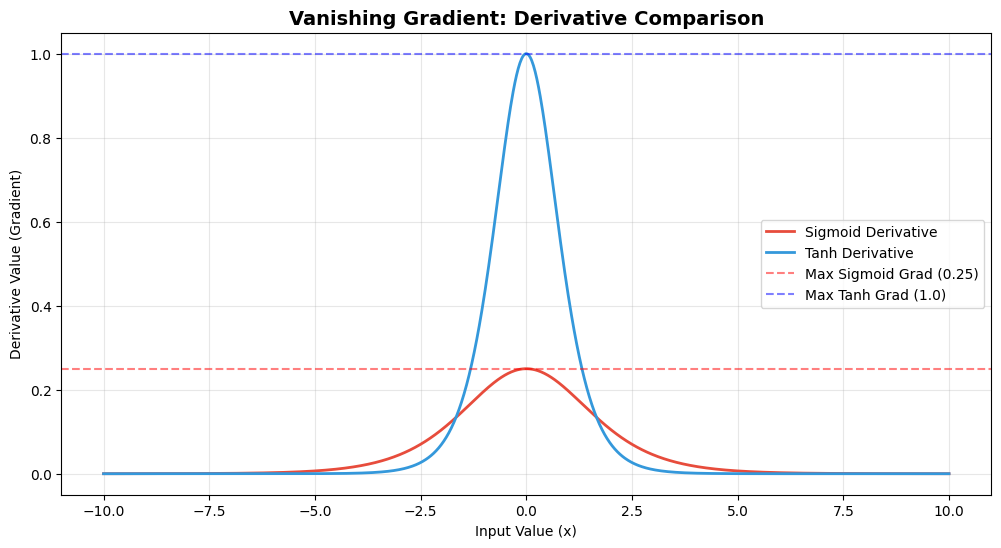

GRADIENT SIGNAL DECAY ACROSS 10 LAYERS (at x=0)
 Layer  Sigmoid Signal  Tanh Signal
     0    1.000000e+00          1.0
     1    2.500000e-01          1.0
     2    6.250000e-02          1.0
     3    1.562500e-02          1.0
     4    3.906250e-03          1.0
     5    9.765625e-04          1.0
     6    2.441406e-04          1.0
     7    6.103516e-05          1.0
     8    1.525879e-05          1.0
     9    3.814697e-06          1.0
    10    9.536743e-07          1.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Define Functions and Derivatives
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1.0 - np.tanh(x)**2

# 2. Setup Input Range
x = np.linspace(-10, 10, 1000)

# 3. Visualization of Derivatives (The "Learning Signal")
plt.figure(figsize=(12, 6))

plt.plot(x, sigmoid_derivative(x), label='Sigmoid Derivative', color='#e74c3c', lw=2)
plt.plot(x, tanh_derivative(x), label='Tanh Derivative', color='#3498db', lw=2)

plt.title('Vanishing Gradient: Derivative Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Input Value (x)')
plt.ylabel('Derivative Value (Gradient)')
plt.axhline(0.25, color='red', linestyle='--', alpha=0.5, label='Max Sigmoid Grad (0.25)')
plt.axhline(1.0, color='blue', linestyle='--', alpha=0.5, label='Max Tanh Grad (1.0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Simulation: Multi-layer Gradient Decay
def simulate_decay(derivative_func, layers, initial_val):
    grad = 1.0
    history = [grad]
    # We take the derivative at the initial_val and multiply it 'layers' times
    d_val = derivative_func(initial_val)
    for _ in range(layers):
        grad *= d_val
        history.append(grad)
    return history

layers = 10
# Simulate decay at a typical initialization point (x=0)
sig_decay = simulate_decay(sigmoid_derivative, layers, 0.0)
tanh_decay = simulate_decay(tanh_derivative, layers, 0.0)

# 5. Decay Table
decay_df = pd.DataFrame({
    'Layer': range(layers + 1),
    'Sigmoid Signal': sig_decay,
    'Tanh Signal': tanh_decay
})

print("="*50)
print("GRADIENT SIGNAL DECAY ACROSS 10 LAYERS (at x=0)")
print("="*50)
print(decay_df.to_string(index=False))